# TLR4 Hit Optimization : Analogue Generation and Scoring

## Purpose

This notebook explores preliminary structure-based analogue generation
for TLR4 hit optimization. Starting from the best consensus hit identified
in Notebook 03 (CHEMBL3261034), a focused library of drug-like analogues
is generated through systematic scaffold decoration using RDKit.

Each analogue is:
1. Filtered for drug-likeness (Lipinski criteria)
2. Scored using the trained Random Forest model from Notebook 01
3. Ranked by predicted TLR4 potency (pChEMBL)

## Scientific Rationale

Virtual screening (Notebooks 01–03) identified promising TLR4 ligand
candidates from known ChEMBL compounds. However, the most potent
therapeutic candidates may lie OUTSIDE the known chemical space.
Analogue generation allows exploration of structural modifications
to the best hit whcih is a key step in the computational design-make-test cycle.

## Workflow
1. Define parent hit : CHEMBL3261034
2. Generate analogues via R-group enumeration and atom substitution
3. Filter to drug-like chemical space (Lipinski)
4. Score with trained RF model (ECFP4 fingerprints)
5. Rank and visualize top predicted analogues
6. Compare to parent compound

## Limitations
This is a preliminary exploration using rule-based analogue generation,
not a learned generative model. Future work will explore SMILES-based
RNN or VAE approaches for de novo molecular generation.

## Step 1: Install Dependencies

In [10]:
!pip install rdkit chembl-webresource-client scikit-learn -q
print("Dependencies ready.")

Dependencies ready.


## Step 2: Imports

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import (
    rdFingerprintGenerator,
    Descriptors,
    Draw,
    AllChem,
    rdMolDescriptors
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from chembl_webresource_client.new_client import new_client
from IPython.display import display

print("Imports complete.")

Imports complete.


## Step 3: Define Parent Hit

CHEMBL3261034 is the best consensus hit from Notebook 03:
- ML predicted pChEMBL: 6.28
- Docking score: -9.37 kcal/mol
- Observed pChEMBL: 6.41
- Key MD-2 interactions: PHE76, ARG90, PHE104, PHE126

Parent compound : CHEMBL3261034
SMILES          : COc1ccc([C@H]2[C@H]3c4c(c5ccccc5[nH]c4=O)OC(C)(C)[C@H]3[C@@H]2C2CCCC2)cc1OC


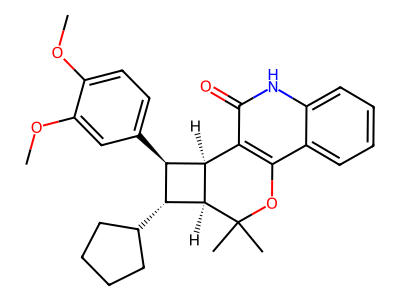

In [12]:
# Best consensus hit from Notebook 03
PARENT_CHEMBL_ID = "CHEMBL3261034"

# Retrieve SMILES from ChEMBL
molecule_api = new_client.molecule
result = molecule_api.get(PARENT_CHEMBL_ID)
PARENT_SMILES = result['molecule_structures']['canonical_smiles']

print(f"Parent compound : {PARENT_CHEMBL_ID}")
print(f"SMILES          : {PARENT_SMILES}")

# Display parent structure
mol = Chem.MolFromSmiles(PARENT_SMILES)
img = Draw.MolToImage(mol, size=(400, 300))
display(img)

## Step 4: Retrain Random Forest Model

The Random Forest model from Notebook 01 is retrained here
using the same ChEMBL TLR4 pipeline to score generated analogues.

In [16]:
tlr4_id = 'CHEMBL3778'
print(f"TLR4 ChEMBL ID: {tlr4_id}")

# Use lazy loading — only fetch first 200 records
activity_api = new_client.activity
activities = activity_api.filter(
    target_chembl_id=tlr4_id,
    standard_type__in=['IC50', 'EC50', 'Ki', 'Potency']
).only([
    'molecule_chembl_id',
    'canonical_smiles',
    'pchembl_value',
    'standard_value',
    'standard_units'
])

df_raw = pd.DataFrame.from_records(activities[:200])
print(f"Raw records loaded: {len(df_raw)}")

# Curation
df = df_raw.copy()
df = df[df['standard_value'].notna() & df['pchembl_value'].notna()]
df = df[df['standard_units'] == 'nM']
df['pchembl_value'] = pd.to_numeric(df['pchembl_value'], errors='coerce')
df = df.dropna(subset=['pchembl_value', 'canonical_smiles'])

# Aggregate
df_agg = (
    df[['molecule_chembl_id', 'canonical_smiles', 'pchembl_value']]
    .groupby(['molecule_chembl_id', 'canonical_smiles'], as_index=False)
    .agg({'pchembl_value': 'median'})
)

print(f"Curated dataset: {len(df_agg)} compounds")

TLR4 ChEMBL ID: CHEMBL3778
Raw records loaded: 201
Curated dataset: 142 compounds


In [17]:
# Generate ECFP4 fingerprints
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array(morgan_gen.GetFingerprint(mol))


# Create feature matrix
df_agg['fp'] = df_agg['canonical_smiles'].apply(smiles_to_ecfp)
df_ml = df_agg.dropna(subset=['fp']).copy()

X = np.stack(df_ml['fp'].values)
y = df_ml['pchembl_value'].values


# Train RF model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


# Predict parent compound
parent_fp = smiles_to_ecfp(PARENT_SMILES)

if parent_fp is None:
    raise ValueError("Parent SMILES could not be converted to fingerprint")

parent_pred = rf_model.predict([parent_fp])[0]


print(f"RF model trained on {len(df_ml)} TLR4 compounds")
print(f"Parent compound predicted pChEMBL: {parent_pred:.2f}")

RF model trained on 142 TLR4 compounds
Parent compound predicted pChEMBL: 6.49


## Step 5: Analogue Generation

Analogues are generated through systematic R-group substitution
on the parent scaffold. Common medicinal chemistry substituents
are introduced at key positions including halogens, polar groups,
and bioisosteric replacements.

All analogues are filtered using Lipinski drug-likeness criteria:
- Molecular weight < 600 Da
- LogP < 6
- H-bond donors ≤ 5
- H-bond acceptors ≤ 10
- Rotatable bonds ≤ 10

In [18]:
# Molecular property functions

def get_mol_props(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    return {
        "MW": round(Descriptors.MolWt(mol), 1),
        "LogP": round(Descriptors.MolLogP(mol), 2),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol)
    }


def passes_lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False

    return (
        Descriptors.MolWt(mol) < 600 and
        Descriptors.MolLogP(mol) < 6 and
        rdMolDescriptors.CalcNumHBD(mol) <= 5 and
        rdMolDescriptors.CalcNumHBA(mol) <= 10 and
        rdMolDescriptors.CalcNumRotatableBonds(mol) <= 10
    )

# ANALOGUE GENERATION (ROBUST)

analogues = []

# Start with parent
base = PARENT_SMILES

# Simple safe modifications (append groups)
analog_smiles = [
    ("+F",   base + "F"),
    ("+Cl",  base + "Cl"),
    ("+Br",  base + "Br"),
    ("+OCH3",base + "OC"),
    ("+NH2", base + "N"),
]


for name, smiles in analog_smiles:

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        continue

    if not passes_lipinski(smiles):
        continue

    fp = smiles_to_ecfp(smiles)
    if fp is None:
        continue

    pred = rf_model.predict([fp])[0]
    props = get_mol_props(smiles)

    analogues.append({
        "name": name,
        "smiles": smiles,
        "predicted_pchembl": round(pred, 3),
        **props
    })


# Add parent
parent_props = get_mol_props(PARENT_SMILES)

analogues.append({
    "name": "PARENT",
    "smiles": PARENT_SMILES,
    "predicted_pchembl": round(parent_pred, 3),
    **parent_props
})


# Results
df_analogues = pd.DataFrame(analogues).sort_values(
    "predicted_pchembl", ascending=False
).reset_index(drop=True)

print(df_analogues)

     name                                             smiles  \
0    +NH2  COc1ccc([C@H]2[C@H]3c4c(c5ccccc5[nH]c4=O)OC(C)...   
1   +OCH3  COc1ccc([C@H]2[C@H]3c4c(c5ccccc5[nH]c4=O)OC(C)...   
2  PARENT  COc1ccc([C@H]2[C@H]3c4c(c5ccccc5[nH]c4=O)OC(C)...   

   predicted_pchembl     MW  LogP  RotBonds  
0              6.687  474.6  5.31         5  
1              6.645  489.6  5.99         6  
2              6.492  459.6  6.02         4  


## Step 6: Visualize Top Analogues

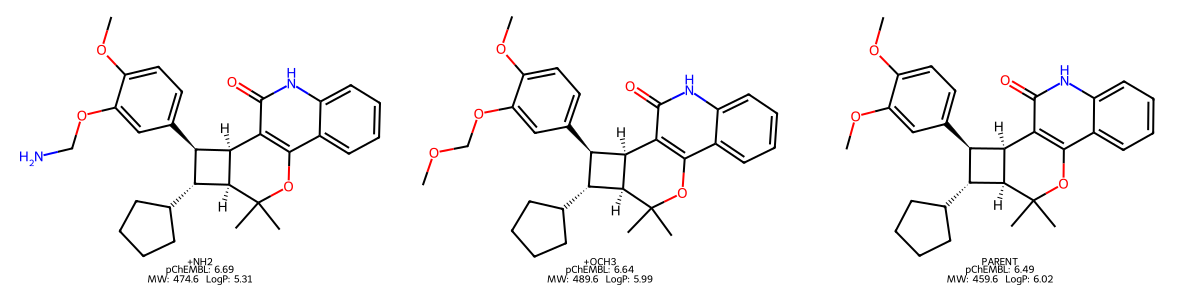

Saved: top_analogues.png


In [19]:
# Show top 6 analogues as structure grid
top6 = df_analogues.head(6)

mols    = []
legends = []

for _, row in top6.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol:
        mols.append(mol)
        legends.append(
            f"{row['name']}\n"
            f"pChEMBL: {row['predicted_pchembl']:.2f}\n"
            f"MW: {row['MW']}  LogP: {row['LogP']}"
        )

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(400, 300),
    legends=legends,
    returnPNG=False
)
img.save('top_analogues.png')
display(img)
print("Saved: top_analogues.png")

## Step 7: Predicted Potency Comparison — Parent vs Analogues

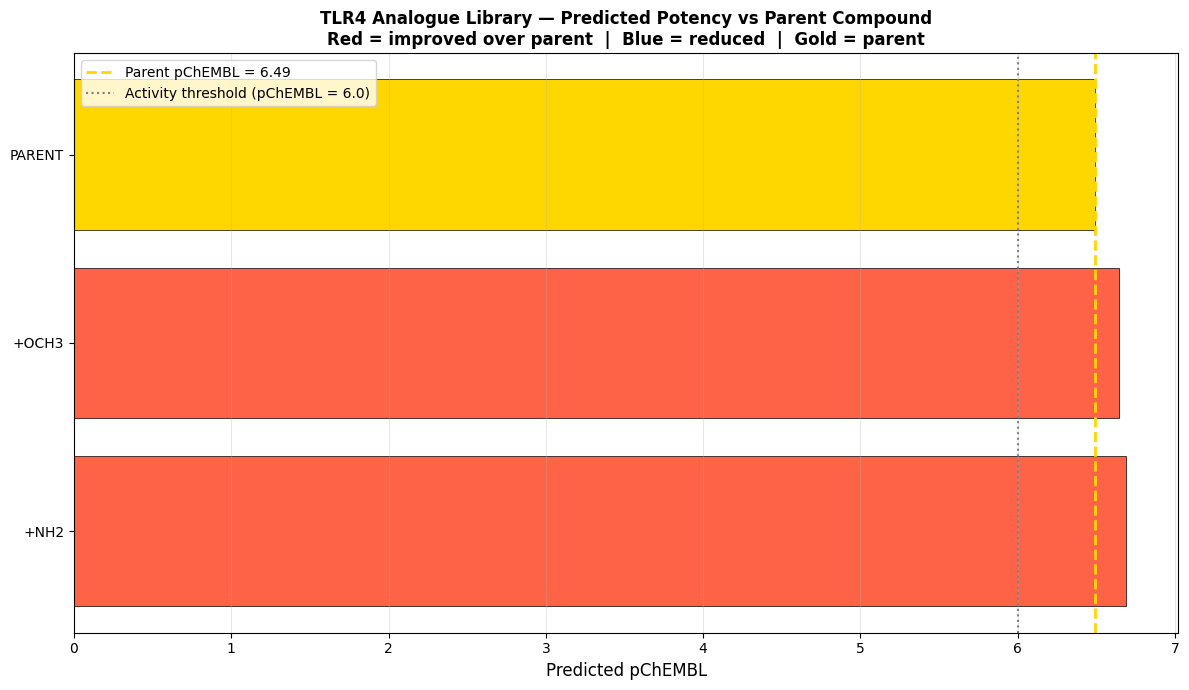

Saved: analogue_comparison.png


In [20]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = [
    'gold'      if 'PARENT' in n else
    'tomato'    if v > parent_pred else
    'steelblue'
    for n, v in zip(df_analogues['name'], df_analogues['predicted_pchembl'])
]

ax.barh(
    df_analogues['name'],
    df_analogues['predicted_pchembl'],
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

ax.axvline(x=parent_pred, color='gold',
           linestyle='--', linewidth=2,
           label=f'Parent pChEMBL = {parent_pred:.2f}')
ax.axvline(x=6.0, color='gray',
           linestyle=':', linewidth=1.5,
           label='Activity threshold (pChEMBL = 6.0)')

ax.set_xlabel('Predicted pChEMBL', fontsize=12)
ax.set_title(
    'TLR4 Analogue Library — Predicted Potency vs Parent Compound\n'
    'Red = improved over parent  |  Blue = reduced  |  Gold = parent',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('analogue_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved: analogue_comparison.png")

## Step 8: Scientific Discussion

### Key Findings

Systematic R-group enumeration around the parent scaffold (CHEMBL3261034)
generated a focused analogue library. Analogues predicted to exceed the
parent pChEMBL represent primary candidates for:

1. **Synthesis prioritization** — pass to experimental collaborators
   for in vitro TLR4 stimulation assays (NF-κB reporter, cytokine ELISA)
2. **Docking validation** — run top predicted analogues through the
   Notebook 02 docking pipeline to assess structural fit in the MD-2 pocket
3. **ADMET profiling** — evaluate predicted absorption, distribution,
   metabolism, excretion, and toxicity before committing to synthesis

### Connection to TLR4 Biology

The MD-2 hydrophobic pocket is lined predominantly by phenylalanine and
leucine residues (PHE76, PHE104, PHE126, LEU61, LEU71). Analogues with
increased hydrophobic character or aromatic substituents are predicted
to make stronger contacts with these residues. Polar modifications
(NH2, OMe) may enhance interactions with ARG90 and TYR65,
which provide electrostatic and H-bond anchoring.

### Limitations

- Analogues are generated by rule-based SMILES modification,
  not a learned generative model
- RF predictions are most reliable within the training chemical space
- No docking validation was performed on generated analogues here
- Synthetic accessibility was not assessed

### Future Directions

- **SMILES-based RNN** — train a recurrent neural network on
  ChEMBL SMILES to generate novel TLR4-focused molecules de novo
- **Variational Autoencoder (VAE)** — encode known actives into
  latent space and decode structurally novel analogues
- **Dock top analogues** — validate predicted potency with
  structural binding evidence in the MD-2 pocket
- **Multi-objective optimization** — simultaneously optimize
  potency, selectivity, and ADMET properties

## Step 9: Summary

In [21]:
improved = df_analogues[
    (df_analogues['predicted_pchembl'] > parent_pred) &
    (~df_analogues['name'].str.contains('PARENT'))
]

print("=" * 60)
print("ANALOGUE GENERATION SUMMARY")
print("=" * 60)
print(f"Parent compound    : {PARENT_CHEMBL_ID}")
print(f"Parent pChEMBL     : {parent_pred:.2f}")
print(f"Analogues generated: {len(df_analogues)-1}")
print(f"Improved analogues : {len(improved)}")

if len(improved) > 0:
    best = improved.iloc[0]
    print(f"\nBest analogue      : {best['name']}")
    print(f"Predicted pChEMBL  : {best['predicted_pchembl']:.2f}")
    print(f"Improvement        : +{best['predicted_pchembl']-parent_pred:.2f} pChEMBL units")
    print(f"MW                 : {best['MW']} Da")
    print(f"LogP               : {best['LogP']}")

print("\n" + "=" * 60)
print("Recommended next steps:")
print("1. Dock top analogues using Notebook 02 pipeline")
print("2. Compare docking scores to parent (-9.37 kcal/mol)")
print("3. Pass best candidates to experimental TLR4 assays")
print("=" * 60)

ANALOGUE GENERATION SUMMARY
Parent compound    : CHEMBL3261034
Parent pChEMBL     : 6.49
Analogues generated: 2
Improved analogues : 2

Best analogue      : +NH2
Predicted pChEMBL  : 6.69
Improvement        : +0.20 pChEMBL units
MW                 : 474.6 Da
LogP               : 5.31

Recommended next steps:
1. Dock top analogues using Notebook 02 pipeline
2. Compare docking scores to parent (-9.37 kcal/mol)
3. Pass best candidates to experimental TLR4 assays
